In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_excel("Amazon.xlsx")
df.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [30]:
df = df.rename(columns={'Unnamed: 0': 'Nombre'})
clientes = df['Nombre'].astype(str).str.strip().str.lower() 
data = df.iloc[:, 2:]      
clientes = clientes.str.strip().str.lower()

In [31]:
from sklearn.preprocessing import normalize
data_scale = normalize(data)

print(data_scale)

[[0.00713538 0.82056845 0.55893793 0.05708302 0.05470456 0.06183994
  0.04994764 0.04043381]
 [0.0387359  0.81345395 0.08521899 0.06455984 0.01032957 0.10846053
  0.5552146  0.07230702]
 [0.08767887 0.96109528 0.01011679 0.14500736 0.09105113 0.13826283
  0.08767887 0.11128472]
 [0.00992558 0.70471612 0.58560917 0.03573208 0.04565766 0.07741952
  0.38709758 0.03374697]
 [0.17963821 0.19161409 0.15568645 0.13572665 0.18363017 0.89819107
  0.13572665 0.17165429]
 [0.25442461 0.6090771  0.03700722 0.04009115 0.02929738 0.74785416
  0.03392328 0.0046259 ]
 [0.02484126 0.98329988 0.06831347 0.07245368 0.09315473 0.07866399
  0.06003305 0.06417326]
 [0.04343202 0.06411394 0.52738883 0.05790936 0.04550021 0.71352607
  0.44466117 0.05997755]
 [0.03182003 0.18694265 0.93471326 0.13921261 0.01193251 0.15114512
  0.10739259 0.19092015]
 [0.3045773  0.56564355 0.00522133 0.06439634 0.05569413 0.75709213
  0.04699193 0.06787723]
 [0.03552259 0.19537426 0.10656778 0.00888065 0.12432907 0.1287694
  0

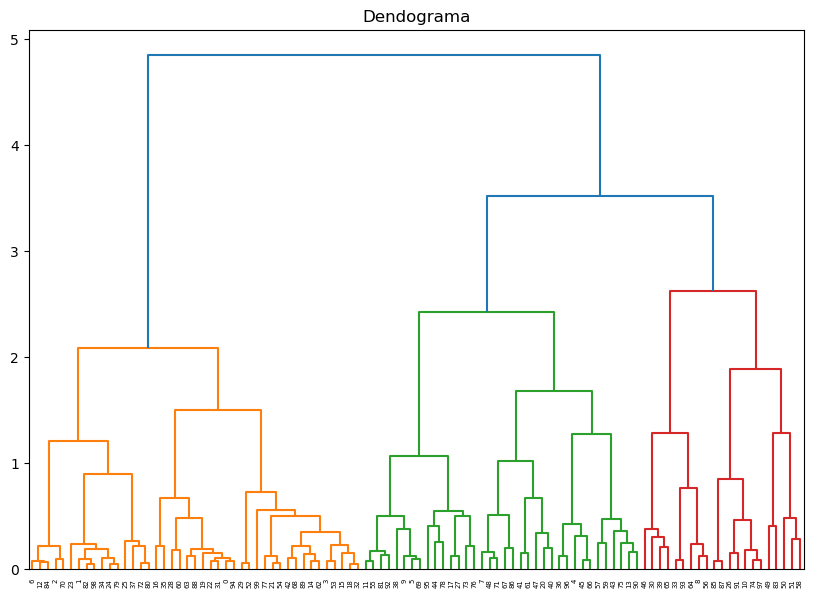

In [32]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,7))
plt.title("Dendograma")
dend=shc.dendrogram(shc.linkage(data_scale, method="ward"))

In [33]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(shc.linkage(data_scale, method="ward"), t=5, criterion='maxclust')

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
1    43
3    21
2    15
5    12
4     9
Name: count, dtype: int64


In [34]:
df['Cluster'] = clusters
print(df[['Cluster']].head())

   Cluster
0        1
1        1
2        1
3        1
4        3


In [35]:
print(df.iloc[:,0].unique())

['Adam' 'Anna' 'Bernard' 'Edward' 'Emilia' 'Fabian' 'Philip' 'Frank'
 'Xavier' 'Gabriel' 'Marisol' 'Henry' 'Irene' 'Isabelle' 'Isidore'
 'Joseph' 'Eugene' 'Eugenia' 'Eunice' 'Eva' 'Evdokia' 'Fedir' 'Felix'
 'Fialka' 'Flavia' 'Flora' 'Florent' 'Florence' 'Hannah' 'Helen' 'Herman'
 'Hilary' 'Lourdes' 'Isadore' 'Ivan' 'Jacob' 'Jeremiah' 'Jervis' 'Joachim'
 'John' 'Santiago' 'Josephine' 'Judith' 'Justin' 'Kalyna' 'Larissa'
 'Lawrence' 'Leon' 'Leonard' 'Leonid' 'Lesia' 'Leo' 'Louise' 'Lubomyr'
 'Lydia' 'Magdalyna' 'Maksym' 'Marcel' 'Margaret' 'Maria' 'Marian'
 'Marianna' 'Markian' 'Marko' 'Martha' 'Martin' 'Maryna' 'Matthew' 'Maura'
 'Maya' 'Maximillian' 'Melania' 'Methodius' 'Michael' 'Michaelina' 'Mina'
 'Monica' 'Mykyta' 'Myron' 'Myroslav' 'Myroslava' 'Salome' 'Samuel'
 'Sandra' 'Sarah' 'Savina' 'Sebastian' 'Sophia' 'Stephan' 'Stephania'
 'Susanna' 'Sylvan' 'Sylvester' 'Tamara' 'Theodore' 'Teofan' 'Teofil'
 'Teofila' 'Teon' 'Teresa']


In [38]:
salome_cluster = df[df.iloc[:,0] == "Salome"]['Cluster'].values[0]
stephania_cluster = df[df.iloc[:,0] == "Stephania"]['Cluster'].values[0]
lydia_cluster = df[df.iloc[:,0] == "Lydia"]['Cluster'].values[0]

In [39]:
clientes = df.iloc[:, 0].astype(str).str.strip().str.lower()
df['Cliente'] = clientes

print(df[['Cliente']].head())

   Cliente
0     adam
1     anna
2  bernard
3   edward
4   emilia


In [40]:
for i in df['Cluster'].unique():
    print(f"\nCluster {i}:")
    print(df[df['Cluster'] == i]['Cliente'])


Cluster 1:
0            adam
1            anna
2         bernard
3          edward
6          philip
12          irene
14        isidore
15         joseph
16         eugene
18         eunice
19            eva
21          fedir
22          felix
23         fialka
24         flavia
25          flora
28         hannah
29          helen
31         hilary
32        lourdes
34           ivan
35          jacob
37         jervis
42         judith
52         louise
53        lubomyr
54          lydia
60         marian
62        markian
63          marko
68          maura
70    maximillian
72      methodius
77         mykyta
79       myroslav
80      myroslava
82         samuel
84          sarah
88        stephan
89      stephania
94       theodore
98           teon
99         teresa
Name: Cliente, dtype: object

Cluster 3:
4        emilia
7         frank
13     isabelle
20      evdokia
36     jeremiah
40     santiago
41    josephine
43       justin
45      larissa
47         leon
48      leona

In [41]:
df[df['Cluster'] == salome_cluster]
df[df['Cluster'] == stephania_cluster]
df[df['Cluster'] == lydia_cluster]

,Nombre,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,Cluster,Cliente
0,Adam,205,3,345,235,24,23,26,21,17,1,adam
1,Anna,9,15,315,33,25,4,42,215,28,1,anna
2,Bernard,17,26,285,3,43,27,41,26,33,1,bernard
3,Edward,135,5,355,295,18,23,39,195,17,1,edward
6,Philip,23,12,475,33,35,45,38,29,31,1,philip
12,Irene,14,7,405,19,21,14,33,22,24,1,irene
14,Isidore,235,65,495,335,3,26,34,295,39,1,isidore
15,Joseph,17,1,485,235,27,17,24,235,34,1,joseph
16,Eugene,16,205,285,255,36,29,31,22,23,1,eugene
18,Eunice,265,7,485,305,33,39,34,295,39,1,eunice


In [42]:
print(df[['Cliente','Cluster']])

    Cliente  Cluster
0      adam        1
1      anna        1
2   bernard        1
3    edward        1
4    emilia        3
..      ...      ...
95   teofan        2
96   teofil        3
97  teofila        5
98     teon        1
99   teresa        1

[100 rows x 2 columns]


In [44]:
cluster_lydia = df[df['Cliente'] == "lydia"]['Cluster'].values[0]
df[df['Cluster'] == cluster_lydia]['Cliente']

0            adam
1            anna
2         bernard
3          edward
6          philip
12          irene
14        isidore
15         joseph
16         eugene
18         eunice
19            eva
21          fedir
22          felix
23         fialka
24         flavia
25          flora
28         hannah
29          helen
31         hilary
32        lourdes
34           ivan
35          jacob
37         jervis
42         judith
52         louise
53        lubomyr
54          lydia
60         marian
62        markian
63          marko
68          maura
70    maximillian
72      methodius
77         mykyta
79       myroslav
80      myroslava
82         samuel
84          sarah
88        stephan
89      stephania
94       theodore
98           teon
99         teresa
Name: Cliente, dtype: object

In [45]:
print(df[df['Cliente'].str.contains('salome', case=False, na=False)])
print(df[df['Cliente'].str.contains('stephania', case=False, na=False)])

for cluster in df['Cluster'].unique():
    print(f"\nCluster {cluster}:")
    print(df[df['Cluster'] == cluster]['Cliente'].tolist())

    Nombre  Velocidad Entrega  Precio  Durabilidad  Imagen Producto  \
81  Salome                 17      23          275               41   

    Valor Educativo  Servicio Retorno  Tamano Paquete  Calidad Producto  \
81                4                44             315                28   

    Numero Estrellas  Cluster Cliente  
81                32        2  salome  
       Nombre  Velocidad Entrega  Precio  Durabilidad  Imagen Producto  \
89  Stephania                215     125          465              315   

    Valor Educativo  Servicio Retorno  Tamano Paquete  Calidad Producto  \
89               34                 4              37               305   

    Numero Estrellas  Cluster    Cliente  
89                45        1  stephania  

Cluster 1:
['adam', 'anna', 'bernard', 'edward', 'philip', 'irene', 'isidore', 'joseph', 'eugene', 'eunice', 'eva', 'fedir', 'felix', 'fialka', 'flavia', 'flora', 'hannah', 'helen', 'hilary', 'lourdes', 'ivan', 'jacob', 'jervis', 'judith',